In [ ]:
# Employee Attrition Analysis

In [1]:
# importing required libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("HR analytics project.csv")

In [4]:
# first 5 rows of the dataframe
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# shape of the dataframe
df.shape

(1470, 35)

In [7]:
# Display column names
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [8]:
# data type of each column
df.dtypes

Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [9]:
# check basic information about the data frame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [10]:
# statistical summary of the data frame
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [12]:
# finding missing values
df.isnull()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1466,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1467,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1468,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# find duplicate rows
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1465    False
1466    False
1467    False
1468    False
1469    False
Length: 1470, dtype: bool

In [18]:
# total number of employees
len(df)

1470

In [19]:
# number of employees who left
len(df[df["Attrition"] == "Yes"])

237

In [20]:
# number of employees who stayed
len(df[df["Attrition"] == "No"])

1233

In [21]:
# attrition percentage
len(df[df["Attrition"] == "Yes"]) * 100 / len(df)

16.122448979591837

In [28]:
# deparment having the highest attrition
employees_left = df[df["Attrition"] == "Yes"]
employees_left.groupby("Department").size().sort_values(ascending = False)

Department
Research & Development    133
Sales                      92
Human Resources            12
dtype: int64

In [30]:
# job role having highest attrition
employees_left = df[df["Attrition"] == "Yes"]
employees_left.groupby("JobRole").size().sort_values(ascending = False)

JobRole
Laboratory Technician        62
Sales Executive              57
Research Scientist           47
Sales Representative         33
Human Resources              12
Manufacturing Director       10
Healthcare Representative     9
Manager                       5
Research Director             2
dtype: int64

In [34]:
# average age of employees who left
employees_left = df[df["Attrition"] == "Yes"]
employees_left["Age"].mean()

np.float64(33.607594936708864)

In [39]:
# Average monthly income (left vs stayed)
df.groupby("Attrition") ["MonthlyIncome"].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

In [36]:
# top 5 education field with highest attrition
employees_left = df[df["Attrition"] == "Yes"]
employees_left.groupby("EducationField").size().sort_values(ascending = False)

EducationField
Life Sciences       89
Medical             63
Marketing           35
Technical Degree    32
Other               11
Human Resources      7
dtype: int64

In [49]:
# attrition rate for each department
employees_left = df[df["Attrition"] == "Yes"]
employees_left.groupby("Department").size() /df.groupby ("Department").size() * 100

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
dtype: float64

In [ ]:
# visualization part using Matplotlib

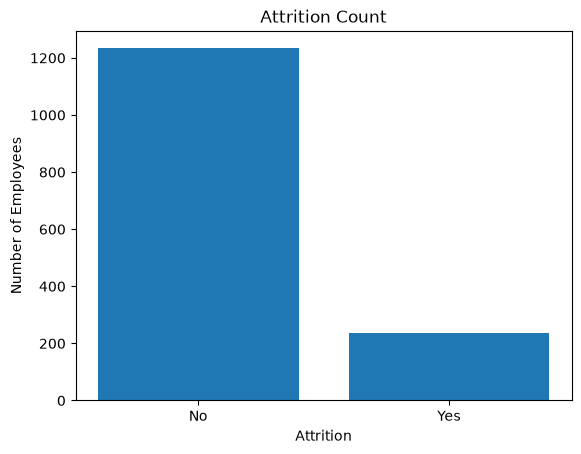

In [51]:
# Bar chart : for attrition
attrition_count = df["Attrition"].value_counts()
plt.bar(attrition_count.index, attrition_count.values)
plt.title("Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

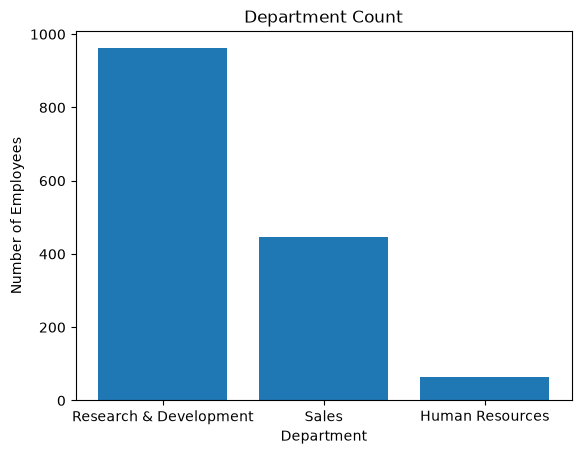

In [52]:
# Number of employees in each department
Department_count = df["Department"].value_counts()
plt.bar(Department_count.index, Department_count.values)
plt.title("Department Count")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.show()

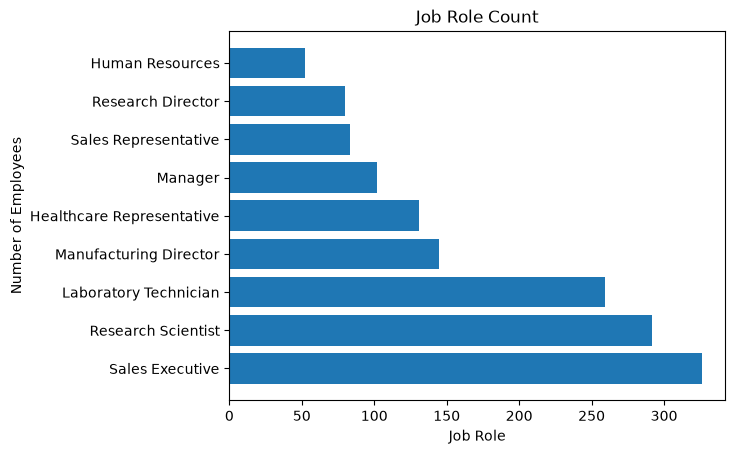

In [60]:
# Employees by job role
jobrole_count = df["JobRole"].value_counts()
plt.barh(jobrole_count.index, jobrole_count.values)
plt.title("Job Role Count")
plt.xlabel("Job Role")
plt.ylabel("Number of Employees")
plt.show()

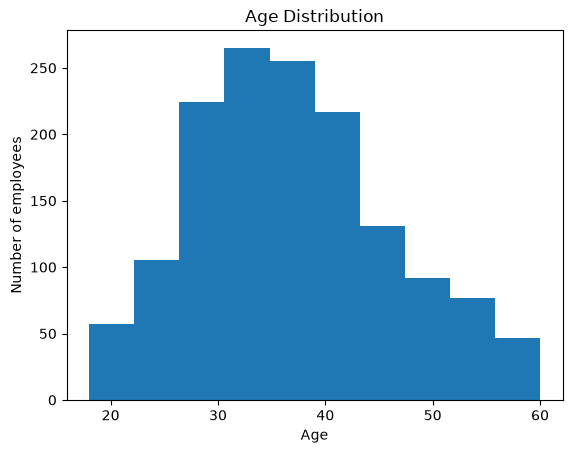

In [65]:
# Age Distribution
plt.hist(df["Age"], bins = 10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of employees")
plt.show()

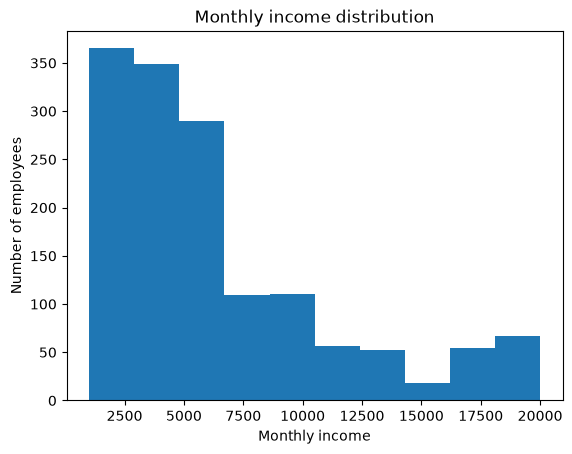

In [66]:
# Monthly income distribution
plt.hist(df["MonthlyIncome"], bins = 10)
plt.title("Monthly income distribution")
plt.xlabel("Monthly income")
plt.ylabel("Number of employees")
plt.show()

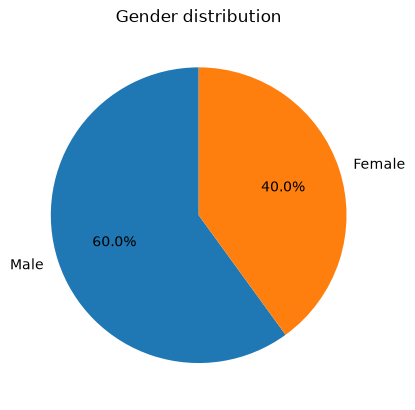

In [67]:
# Gender distribution
Gender_count = df["Gender"].value_counts()
plt.pie(Gender_count.values, labels=Gender_count.index,autopct="%1.1f%%", startangle=90)
plt.title("Gender distribution")
plt.show()

In [ ]:
# Key Insights

- Total employees: 1,470
    
- Employees who left: 237
    
- Attrition rate is highest in the sales department
    
- Sales representative have the highest attrition rate among job roles
    
- Employees who left have a lower average monthly income than those who stayed
    
- Most employees are between 30 - 40 years old
    
- Life Sciences has the highest number of employees who left